# NB12 · Final Hub Selection

**Purpose:** Select the final drone-delivery hub set from NB10 parking candidates using NB11 route-feasibility outputs.

> This notebook does **NOT** perform ETA / motorcycle-vs-drone mode comparison (→ NB13).

## Selection philosophy
| Principle | Implementation |
|---|---|
| Primary scenario | `approval-required` (관제권 = flag, not hard exclusion) |
| Strict scenario | Sensitivity / comparison only |
| Optimization objective | Maximum weighted demand coverage (Ds) with spatial balance |
| Algorithm | Greedy incremental coverage, repeated for k = 3…8 |
| Recommended k | **5** |

## Inputs
| File | Content |
|---|---|
| `nb11_candidate_route_summary.csv` | Per-lot route metrics from NB11 |
| `nb11_route_pairs.csv` | Per-route-pair feasibility table from NB11 |
| `final_candidate_sites.gpkg` | Candidate site geometries + NB10 scores |
| `delivery_zones.gpkg` | H3 demand cells |
| `candidate_h3_coverage.parquet` | NB10 coverage (row-count validation) |
| `seongnam_boundary.gpkg` | Admin boundaries |

## Outputs (`processed/nb12_*`)
| File | Content |
|---|---|
| `nb12_final_hubs.csv` | Selected hubs with scores and assignment stats |
| `nb12_final_hubs.gpkg` | Same, with point geometry |
| `nb12_hub_service_assignments.csv` | Target H3 → assigned hub mapping |
| `nb12_selection_scenarios.csv` | Scenario table k = 3…8 |
| `nb12_final_hub_map.html` | Interactive Folium map |
| `nb12_selection_chart.png` | Coverage curve + score components |
| `nb12_selection_diagnostics.json` | Validation record for downstream NB13 |


In [1]:
# ── CELL 1 · Setup & Constants ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import folium
from folium.plugins import MarkerCluster
from branca.colormap import linear as bl

ROOT     = Path(r'C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset')
PROC     = ROOT / 'processed'
CRS_PROJ = 'EPSG:5179'

# Hub selection constants
K_RECOMMENDED    = 6
K_SCENARIOS      = [3, 4, 5, 6, 7, 8]
CLUSTER_DIST_M   = 800    # spatial penalty radius (m)
CLUSTER_PENALTY  = 0.10   # subtracted from greedy score if within radius
MIN_ELIGIBLE_APPROVAL = 1 # min drone_feasible_approval_count to be eligible

# Scoring weights — final_hub_base_score
W_NB10   = 0.25
W_ROUTE  = 0.30
W_DEMAND = 0.20
W_TIME   = 0.10
W_AIRSP  = 0.10
W_ROBOT  = 0.05

# Greedy increment weights
GW_DS      = 0.45
GW_COUNT   = 0.20
GW_BASE    = 0.20
GW_TIME    = 0.10
GW_ROBOT   = 0.05

print('✓ Setup complete')
print(f'  Recommended k = {K_RECOMMENDED}  |  Scenarios = {K_SCENARIOS}')
print(f'  Cluster penalty radius = {CLUSTER_DIST_M} m')

✓ Setup complete
  Recommended k = 6  |  Scenarios = [3, 4, 5, 6, 7, 8]
  Cluster penalty radius = 800 m


In [2]:
# ── CELL 2 · Input Validation ─────────────────────────────────────────────────
# Gate on NB11 outputs — fail fast with clear message if missing.

NB11_REQUIRED = [
    PROC / 'nb11_route_pairs.csv',
    PROC / 'nb11_candidate_route_summary.csv',
    PROC / 'nb11_route_analysis.gpkg',
    PROC / 'nb11_route_diagnostics.json',
]
missing_nb11 = [p for p in NB11_REQUIRED if not p.exists()]
if missing_nb11:
    msg = (
        'Run corrected NB11_route_feasibility_analysis.ipynb first.\n'
        'Missing NB11 outputs:\n'
        + '\n'.join(f'  - {p.name}' for p in missing_nb11)
    )
    raise FileNotFoundError(msg)

OTHER_REQUIRED = [
    PROC / 'final_candidate_sites.gpkg',
    PROC / 'delivery_zones.gpkg',
    PROC / 'candidate_h3_coverage.parquet',
    PROC / 'seongnam_boundary.gpkg',
]
missing_other = [p for p in OTHER_REQUIRED if not p.exists()]
if missing_other:
    raise FileNotFoundError('Missing required inputs:\n' + '\n'.join(f'  - {p}' for p in missing_other))

print('✓ All required files found')

# ── Row-count sanity: nb11_route_pairs must equal candidate_h3_coverage ────────
nb11_pair_count = len(pd.read_csv(PROC / 'nb11_route_pairs.csv'))
cov_count       = len(pd.read_parquet(PROC / 'candidate_h3_coverage.parquet'))
if nb11_pair_count != cov_count:
    raise ValueError(
        f'nb11_route_pairs.csv has {nb11_pair_count} rows but '
        f'candidate_h3_coverage.parquet has {cov_count} rows.\n'
        'NB11 may still be using old cross-join logic. '
        'Run corrected NB11_route_feasibility_analysis.ipynb first.'
    )
print(f'✓ nb11_route_pairs row count matches coverage parquet: {nb11_pair_count}')

# ── Load NB11 diagnostics for reference ───────────────────────────────────────
with open(PROC / 'nb11_route_diagnostics.json') as f:
    nb11_diag = json.load(f)
print('\nNB11 diagnostics:')
for k, v in nb11_diag.items():
    print(f'  {k}: {v}')

✓ All required files found
✓ nb11_route_pairs row count matches coverage parquet: 2089

NB11 diagnostics:
  total_route_pairs: 2089
  unique_lot_id_count: 171
  unique_target_h3_count: 183
  site_ADM_NM_null_count: 0
  site_GU_NM_null_count: 0
  drone_direct_feasible_approval: 2089
  drone_direct_feasible_strict: 25
  robot_handoff_feasible: 2084
  airspace_approval_required: 2064
  route_crosses_airspace_exclusion: 2064
  route_crosses_non_airspace_hard_exclusion: 0
  route_crosses_hard_exclusion: 0
  valid_drone_geometries: 2089
  elev_min_m_non_null: 2089
  mean_slope_deg_non_null: 2089
  route_mean_constraint_score_non_null: 2089
  rfi_approval_mean: 0.5564807017543859
  rfi_approval_max: 0.7882
  rfi_strict_mean: 0.014847368421052632
  network_used: True
  has_dem: True
  has_slope: True
  has_airspace: True


In [3]:
# ── CELL 3 · Load All Inputs ──────────────────────────────────────────────────

def _gpkg(p, layer):
    gdf = gpd.read_file(p, layer=layer)
    print(f'  ✓ {Path(p).name} [{layer}] → {len(gdf)} rows, CRS={gdf.crs.to_epsg()}')
    return gdf

print('Loading inputs…')
sites_raw  = _gpkg(PROC / 'final_candidate_sites.gpkg', 'final_candidate_sites')
zones_gdf  = _gpkg(PROC / 'delivery_zones.gpkg',        'delivery_zones')
bnd_city   = _gpkg(PROC / 'seongnam_boundary.gpkg',     'city')
bnd_dong   = _gpkg(PROC / 'seongnam_boundary.gpkg',     'dong')

nb11_pairs   = pd.read_csv(PROC / 'nb11_route_pairs.csv',         low_memory=False)
nb11_summary = pd.read_csv(PROC / 'nb11_candidate_route_summary.csv')
coverage_df  = pd.read_parquet(PROC / 'candidate_h3_coverage.parquet')

print(f'  ✓ nb11_route_pairs.csv → {len(nb11_pairs)} rows, {nb11_pairs.shape[1]} cols')
print(f'  ✓ nb11_candidate_route_summary.csv → {len(nb11_summary)} rows')
print(f'  ✓ candidate_h3_coverage.parquet → {len(coverage_df)} rows')

# ── Column validation ─────────────────────────────────────────────────────────
REQUIRED_PAIR_COLS = [
    'lot_id', 'target_h3_index', 'Ds', 'delivery_zone',
    'target_ADM_NM', 'target_GU_NM', 'drone_time_min',
    'route_mean_constraint_score', 'airspace_approval_required',
    'drone_direct_feasible_approval', 'drone_direct_feasible_strict',
    'robot_handoff_feasible', 'within_1km_centroid',
]
REQUIRED_SUMM_COLS = [
    'lot_id', 'lot_name', 'site_ADM_NM', 'site_GU_NM',
    'candidate_rank', 'candidate_grade', 'candidate_score_for_ranking',
    'route_feasibility_index_approval', 'route_feasibility_index_strict',
    'drone_feasible_approval_count', 'served_Ds_sum_approval',
    'demand_weighted_drone_time_min', 'mean_route_constraint_score',
    'airspace_approval_required_count', 'robot_handoff_feasible_count',
]
miss_pair = [c for c in REQUIRED_PAIR_COLS if c not in nb11_pairs.columns]
miss_summ = [c for c in REQUIRED_SUMM_COLS if c not in nb11_summary.columns]
if miss_pair:
    raise ValueError(f'nb11_route_pairs missing columns: {miss_pair}')
if miss_summ:
    raise ValueError(f'nb11_candidate_route_summary missing columns: {miss_summ}')
print('\n✓ All required columns present')
print(f'  Unique lot_id in pairs   : {nb11_pairs["lot_id"].nunique()}')
print(f'  Unique lot_id in summary : {nb11_summary["lot_id"].nunique()}')

Loading inputs…


  ✓ final_candidate_sites.gpkg [final_candidate_sites] → 171 rows, CRS=4326


  ✓ delivery_zones.gpkg [delivery_zones] → 283 rows, CRS=4326
  ✓ seongnam_boundary.gpkg [city] → 1 rows, CRS=4326
  ✓ seongnam_boundary.gpkg [dong] → 50 rows, CRS=4326
  ✓ nb11_route_pairs.csv → 2089 rows, 52 cols
  ✓ nb11_candidate_route_summary.csv → 171 rows
  ✓ candidate_h3_coverage.parquet → 2089 rows

✓ All required columns present
  Unique lot_id in pairs   : 171
  Unique lot_id in summary : 171


In [4]:
# ── CELL 4 · Prepare Candidate Table ─────────────────────────────────────────
# Merge NB10 site attributes + NB11 route summary by lot_id.

# NB10 attributes to pull from sites_raw
NB10_COLS = [
    'lot_id', 'lot_name', 'parking_site_score',
    'demand_context_score', 'constraint_context_score',
    'candidate_score_for_ranking', 'candidate_rank', 'candidate_grade',
    'ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'geometry',
]
nb10_df = sites_raw[[c for c in NB10_COLS if c in sites_raw.columns]].copy()

# NB11 route-summary attributes
NB11_SUMM_KEEP = [
    'lot_id', 'lot_name', 'site_ADM_NM', 'site_GU_NM',
    'total_route_pairs', 'strict_1km_pairs',
    'drone_feasible_approval_count', 'drone_feasible_strict_count',
    'robot_handoff_feasible_count', 'airspace_approval_required_count',
    'mean_drone_time_min', 'mean_robot_time_min_adjusted',
    'demand_weighted_drone_time_min',
    'served_Ds_sum_approval', 'served_Ds_sum_strict',
    'mean_route_constraint_score',
    'route_feasibility_index_approval', 'route_feasibility_index_strict',
    'nb11_route_note',
]
nb11_keep = [c for c in NB11_SUMM_KEEP if c in nb11_summary.columns]
nb11_df   = nb11_summary[nb11_keep].copy()

# Merge — NB11 site_ADM_NM / site_GU_NM takes precedence over NB10 ADM_NM / GU_NM
cands = nb10_df.merge(nb11_df, on='lot_id', how='left', suffixes=('_nb10', ''))

# Prefer NB11 lot_name if available (NB11 has authoritative lot_name)
if 'lot_name_nb10' in cands.columns and 'lot_name' in cands.columns:
    cands['lot_name'] = cands['lot_name'].fillna(cands['lot_name_nb10'])
    cands = cands.drop(columns=['lot_name_nb10'], errors='ignore')

# Prefer NB11 site_ADM_NM/GU_NM; fall back to NB10 ADM_NM/GU_NM
if 'site_ADM_NM' not in cands.columns:
    cands['site_ADM_NM'] = cands.get('ADM_NM', None)
if 'site_GU_NM' not in cands.columns:
    cands['site_GU_NM'] = cands.get('GU_NM', None)

# Make GeoDataFrame
cands_gdf = gpd.GeoDataFrame(cands, geometry='geometry', crs=sites_raw.crs)

# ── Eligibility filter ────────────────────────────────────────────────────────
n_before = len(cands_gdf)
cands_gdf['_eligible'] = (
    cands_gdf.geometry.notna() &
    (cands_gdf['drone_feasible_approval_count'].fillna(0) >= MIN_ELIGIBLE_APPROVAL) &
    cands_gdf['route_feasibility_index_approval'].notna() &
    (cands_gdf['total_route_pairs'].fillna(0) > 0) &
    cands_gdf['candidate_score_for_ranking'].notna()
)
# NOTE: candidates with airspace_approval_required_count > 0 remain eligible.
# Their approval burden is penalised in scoring, not used as a hard exclusion.

cands_eligible = cands_gdf[cands_gdf['_eligible']].copy().reset_index(drop=True)
n_after = len(cands_eligible)
print(f'✓ Candidate table: {n_before} total → {n_after} eligible')
print(f'  Ineligible (insufficient route feasibility): {n_before - n_after}')

if n_after < max(K_SCENARIOS):
    print(f'  ⚠ WARNING: only {n_after} eligible candidates — k={max(K_SCENARIOS)} will not be reachable')

# Project to 5179 for distance calculations
cands_5179 = cands_eligible.to_crs(CRS_PROJ) if cands_eligible.crs.to_epsg() != 5179 else cands_eligible.copy()
lot_geom_map = dict(zip(cands_5179['lot_id'], cands_5179.geometry))  # for clustering check

cands_eligible.head(3)[[
    'lot_id', 'lot_name', 'candidate_rank', 'candidate_grade',
    'drone_feasible_approval_count', 'served_Ds_sum_approval',
    'route_feasibility_index_approval'
]]

✓ Candidate table: 171 total → 171 eligible
  Ineligible (insufficient route feasibility): 0


,lot_id,lot_name,candidate_rank,candidate_grade,drone_feasible_approval_count,served_Ds_sum_approval,route_feasibility_index_approval
0,206-2-000011,수내역환승,1,A,12,5.512513,0.6869
1,206-2-000015,판교공영,2,A,12,4.916900,0.6745
2,206-3-000001,분당구청 부설주차장,3,A,13,6.206305,0.7093


In [5]:
# ── CELL 5 · Prepare Route Assignment Table ───────────────────────────────────
# Filter nb11_route_pairs to approval-feasible routes from eligible candidates.

eligible_ids = set(cands_eligible['lot_id'])

# Primary: approval-feasible routes from eligible candidates
routes_all = nb11_pairs[
    nb11_pairs['lot_id'].isin(eligible_ids) &
    nb11_pairs['drone_direct_feasible_approval'].astype(bool)
].copy()

# Diagnostic: 1km-only coverage density
routes_1km = routes_all[routes_all['within_1km_centroid'].astype(bool)]
n_1km_h3   = routes_1km['target_h3_index'].nunique()
n_all_h3   = routes_all['target_h3_index'].nunique()
print(f'Approval-feasible routes: {len(routes_all):,}')
print(f'  Unique target H3 covered (all approval): {n_all_h3}')
print(f'  Unique target H3 covered (within 1km)  : {n_1km_h3}')

# Use all approval-feasible routes for selection (not 1km-only)
# 1km flag is kept as a field for downstream filtering / reporting
if n_1km_h3 < n_all_h3 * 0.5:
    print('  ℹ Using all approval-feasible pairs (1km coverage is <50% of total).')
routes = routes_all.copy()

# Ensure boolean types
for col in ['drone_direct_feasible_approval', 'drone_direct_feasible_strict',
            'robot_handoff_feasible', 'airspace_approval_required', 'within_1km_centroid']:
    if col in routes.columns:
        routes[col] = routes[col].astype(bool)

# Build target lookup: h3_index → Ds, priority_zone
target_info = (
    routes.groupby('target_h3_index')
    .agg(Ds=('Ds', 'first'),
         delivery_zone=('delivery_zone', 'first'),
         target_ADM_NM=('target_ADM_NM', 'first'),
         target_GU_NM=('target_GU_NM', 'first'))
    .reset_index()
)

# Lot → set of feasible target_h3_index
lot_targets = (
    routes.groupby('lot_id')['target_h3_index']
    .apply(set).to_dict()
)

# Lot → h3 → drone_time_min (for time-based incremental scoring)
lot_h3_time = (
    routes.groupby(['lot_id', 'target_h3_index'])['drone_time_min']
    .min().unstack(level='target_h3_index', fill_value=np.nan)
)

# Lot → h3 → robot_handoff_feasible
lot_h3_robot = (
    routes.groupby(['lot_id', 'target_h3_index'])['robot_handoff_feasible']
    .any().unstack(level='target_h3_index', fill_value=False)
)

# Ds lookup
h3_ds = target_info.set_index('target_h3_index')['Ds'].to_dict()

print(f'\n✓ Route table ready: {len(routes):,} routes')
print(f'  Lots with any coverage: {len(lot_targets)}')
print(f'  Total unique target H3: {len(h3_ds)}')

Approval-feasible routes: 2,089
  Unique target H3 covered (all approval): 183
  Unique target H3 covered (within 1km)  : 138

✓ Route table ready: 2,089 routes
  Lots with any coverage: 171
  Total unique target H3: 183


In [6]:
# ── CELL 6 · Compute final_hub_base_score ─────────────────────────────────────
# Normalized composite from NB10 + NB11 components.

def _minmax(s, invert=False):
    """Min-max normalise a Series to [0,1]. Returns 0.5 if constant."""
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    n = (s - mn) / (mx - mn)
    return (1.0 - n) if invert else n

c = cands_eligible.copy()

# Component normalisation
c['_n_nb10']   = _minmax(c['candidate_score_for_ranking'].fillna(0))
c['_n_route']  = _minmax(c['route_feasibility_index_approval'].fillna(0))
c['_n_demand'] = _minmax(c['served_Ds_sum_approval'].fillna(0))
c['_n_time']   = _minmax(c['demand_weighted_drone_time_min'].fillna(
                             c['mean_drone_time_min'].fillna(999)), invert=True)

# Approval burden: ratio of routes needing approval (lower = better)
total_pairs = c['total_route_pairs'].replace(0, np.nan)
approval_ratio = c['airspace_approval_required_count'].fillna(0) / total_pairs.fillna(1)
c['_n_airsp']  = _minmax(approval_ratio.fillna(0), invert=True)

c['_n_robot']  = _minmax(c['robot_handoff_feasible_count'].fillna(0))

# Composite
c['final_hub_base_score'] = (
    W_NB10   * c['_n_nb10']   +
    W_ROUTE  * c['_n_route']  +
    W_DEMAND * c['_n_demand'] +
    W_TIME   * c['_n_time']   +
    W_AIRSP  * c['_n_airsp']  +
    W_ROBOT  * c['_n_robot']
).clip(0, 1).round(4)

# Write back to cands_eligible
cands_eligible = c.drop(columns=[col for col in c.columns if col.startswith('_n_')])

# ── Score component distribution ──────────────────────────────────────────────
base_scores = cands_eligible['final_hub_base_score']
print('final_hub_base_score distribution:')
print(f'  min={base_scores.min():.3f}  mean={base_scores.mean():.3f}  '
      f'max={base_scores.max():.3f}  std={base_scores.std():.3f}')
print('\nTop 10 by final_hub_base_score:')
print(
    cands_eligible[['lot_id','lot_name','candidate_rank','candidate_grade',
                    'final_hub_base_score','route_feasibility_index_approval',
                    'served_Ds_sum_approval']]
    .sort_values('final_hub_base_score', ascending=False)
    .head(10)
    .to_string(index=False)
)

# Base score lookup for greedy loop
base_score_map = dict(zip(cands_eligible['lot_id'], cands_eligible['final_hub_base_score']))

final_hub_base_score distribution:
  min=0.166  mean=0.491  max=0.815  std=0.118

Top 10 by final_hub_base_score:
      lot_id     lot_name  candidate_rank candidate_grade  final_hub_base_score  route_feasibility_index_approval  served_Ds_sum_approval
206-2-000023     정자동공영주차장               7               A                0.8149                            0.7882                5.617592
206-2-000011        수내역환승               1               A                0.7555                            0.6869                5.512513
206-3-000001   분당구청 부설주차장               3               A                0.7526                            0.7093                6.206305
206-2-000020 백현동카페거리공영주차장               6               A                0.7469                            0.7104                5.906586
206-2-000007        정자역환승               5               A                0.7334                            0.7075                5.215980
206-2-000015         판교공영               2               A 

In [7]:
# ── CELL 7 · Greedy Maximum Coverage Selection ────────────────────────────────
# Runs for each k in K_SCENARIOS and records full selection sequence.

def _norm_vec(vals):
    """Normalise an array of values to [0,1]; returns 0.5 if constant."""
    arr = np.array(vals, dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn:
        return np.full_like(arr, 0.5)
    return (arr - mn) / (mx - mn)

def _dist_m(geom_a, geom_b):
    """Euclidean distance between two EPSG:5179 Points."""
    try:
        return geom_a.distance(geom_b)
    except Exception:
        return np.inf

def greedy_select(candidate_ids, lot_targets, lot_h3_time, lot_h3_robot,
                  h3_ds, base_score_map, lot_geom_map, k,
                  cluster_dist=CLUSTER_DIST_M, cluster_penalty=CLUSTER_PENALTY):
    """
    Greedy weighted set-cover selection.
    Returns list of dicts: {lot_id, selected_order, greedy_increment_score,
                             incremental_Ds, incremental_targets, covered_h3_set}
    """
    remaining      = set(candidate_ids)
    covered_h3     = set()
    selected       = []          # list of lot_ids in selection order
    selected_geoms = []          # geometries of selected hubs (for clustering)
    selection_log  = []

    for step in range(k):
        if not remaining:
            break

        # ── Per-candidate incremental metrics ─────────────────────────────────
        cand_list        = list(remaining)
        inc_ds_list      = []
        inc_cnt_list     = []
        inc_time_list    = []   # mean drone time for newly covered targets
        inc_robot_list   = []   # count of newly covered targets with robot
        base_list        = []
        cluster_pen_list = []

        for lid in cand_list:
            targets_this = lot_targets.get(lid, set())
            new_h3       = targets_this - covered_h3

            inc_ds    = sum(h3_ds.get(h, 0.0) for h in new_h3)
            inc_cnt   = len(new_h3)

            # Mean drone time for newly covered H3 cells
            if inc_cnt > 0 and lid in lot_h3_time.index:
                times = [lot_h3_time.loc[lid, h] for h in new_h3
                         if h in lot_h3_time.columns and not np.isnan(lot_h3_time.loc[lid, h])]
                inc_time = np.mean(times) if times else 999.0
            else:
                inc_time = 999.0

            # Robot support for newly covered targets
            if inc_cnt > 0 and lid in lot_h3_robot.index:
                rob = sum(1 for h in new_h3
                          if h in lot_h3_robot.columns and lot_h3_robot.loc[lid, h])
            else:
                rob = 0

            # Clustering penalty
            geom_a = lot_geom_map.get(lid)
            pen = 0.0
            if geom_a is not None and selected_geoms:
                min_d = min(_dist_m(geom_a, g) for g in selected_geoms)
                if min_d < cluster_dist:
                    pen = cluster_penalty

            inc_ds_list.append(inc_ds)
            inc_cnt_list.append(float(inc_cnt))
            inc_time_list.append(inc_time)
            inc_robot_list.append(float(rob))
            base_list.append(base_score_map.get(lid, 0.5))
            cluster_pen_list.append(pen)

        # ── Normalise within this round ────────────────────────────────────────
        n_ds    = _norm_vec(inc_ds_list)
        n_cnt   = _norm_vec(inc_cnt_list)
        n_time  = 1.0 - _norm_vec(inc_time_list)  # lower time = better
        n_robot = _norm_vec(inc_robot_list)
        n_base  = np.array(base_list)
        n_pen   = np.array(cluster_pen_list)

        scores = (
            GW_DS    * n_ds    +
            GW_COUNT * n_cnt   +
            GW_BASE  * n_base  +
            GW_TIME  * n_time  +
            GW_ROBOT * n_robot -
            n_pen
        )

        best_idx = int(np.argmax(scores))
        best_lid = cand_list[best_idx]

        # Stop early if no new coverage at all
        if inc_ds_list[best_idx] == 0 and inc_cnt_list[best_idx] == 0:
            print(f'  Step {step+1}: no candidate adds new coverage — stopping early at k={step}')
            break

        # Record selection
        new_h3_selected = lot_targets.get(best_lid, set()) - covered_h3
        covered_h3.update(new_h3_selected)
        remaining.discard(best_lid)
        selected.append(best_lid)
        geom_sel = lot_geom_map.get(best_lid)
        if geom_sel is not None:
            selected_geoms.append(geom_sel)

        selection_log.append({
            'selected_order':          step + 1,
            'lot_id':                  best_lid,
            'greedy_increment_score':  float(round(scores[best_idx], 4)),
            'incremental_Ds':          float(round(inc_ds_list[best_idx], 4)),
            'incremental_targets':     int(inc_cnt_list[best_idx]),
            'cumulative_Ds':           float(round(sum(h3_ds.get(h, 0) for h in covered_h3), 4)),
            'cumulative_targets':      len(covered_h3),
            'clustering_penalised':    bool(cluster_pen_list[best_idx] > 0),
        })

    return selection_log


# ── Run for all k scenarios ───────────────────────────────────────────────────
candidate_ids = list(cands_eligible['lot_id'])
scenario_logs = {}  # k → full log (up to k entries)

# Run once for max k and slice for smaller k (saves recomputation)
MAX_K   = max(K_SCENARIOS)
full_log = greedy_select(
    candidate_ids, lot_targets, lot_h3_time, lot_h3_robot,
    h3_ds, base_score_map, lot_geom_map, k=MAX_K
)

# Build per-k slices
for k in K_SCENARIOS:
    scenario_logs[k] = full_log[:k]

print('\nGreedy selection sequence (up to k=8):')
print(f'  {"Order":<6} {"lot_id":<20} {"Inc Ds":>8} {"Inc Tgt":>8} {"Cum Ds":>8} {"Cum Tgt":>8} {"Penalised"}')
for row in full_log:
    print(f'  {row["selected_order"]:<6} {row["lot_id"]:<20} '
          f'{row["incremental_Ds"]:>8.3f} {row["incremental_targets"]:>8} '
          f'{row["cumulative_Ds"]:>8.3f} {row["cumulative_targets"]:>8} '
          f'{"⚠" if row["clustering_penalised"] else ""}')


Greedy selection sequence (up to k=8):
  Order  lot_id                 Inc Ds  Inc Tgt   Cum Ds  Cum Tgt Penalised
  1      206-3-000001            6.206       13    6.206       13 
  2      204-2-000018            5.159       14   11.366       27 
  3      206-2-000004            4.837       13   16.203       40 
  4      206-2-000022            4.400       14   20.603       54 
  5      206-3-000004            4.527       13   25.131       67 
  6      206-2-000005            3.958       10   29.089       77 
  7      205-2-000019            3.864       12   32.953       89 
  8      205-2-000002            3.424       11   36.377      100 


In [8]:
# ── CELL 8 · Recommended k=5 Selection & Target Assignment ───────────────────

rec_log    = scenario_logs[K_RECOMMENDED]
sel_lot_ids = [r['lot_id'] for r in rec_log]
n_selected  = len(sel_lot_ids)

if n_selected < K_RECOMMENDED:
    print(f'⚠ Only {n_selected} hubs could be selected (coverage exhausted before k={K_RECOMMENDED})')
else:
    print(f'✓ {K_RECOMMENDED} hubs selected')

# ── Build selected-hub records ────────────────────────────────────────────────
greedy_info = {r['lot_id']: r for r in rec_log}

final_hubs = cands_eligible[cands_eligible['lot_id'].isin(sel_lot_ids)].copy()
final_hubs['selected_order']         = final_hubs['lot_id'].map(
    {r['lot_id']: r['selected_order'] for r in rec_log})
final_hubs['greedy_increment_score'] = final_hubs['lot_id'].map(
    {r['lot_id']: r['greedy_increment_score'] for r in rec_log})
final_hubs = final_hubs.sort_values('selected_order').reset_index(drop=True)

# ── Target assignment: each H3 → the selected hub with lowest drone_time_min ──
# Consider only approval-feasible routes from selected hubs
sel_routes = routes[routes['lot_id'].isin(sel_lot_ids)].copy()

# For each (h3, lot) pair keep the minimum drone_time_min row
best_route = (
    sel_routes
    .sort_values(['target_h3_index', 'drone_time_min',
                  'route_mean_constraint_score', 'lot_id'],
                 ascending=[True, True, False, True])
    .groupby('target_h3_index', as_index=False)
    .first()
)

# Tie-break: if two hubs have same time, prefer higher final_hub_base_score
best_route['_lot_base'] = best_route['lot_id'].map(base_score_map)
best_route = (
    best_route
    .sort_values(['target_h3_index', 'drone_time_min', '_lot_base'],
                 ascending=[True, True, False])
    .groupby('target_h3_index', as_index=False)
    .first()
    .drop(columns=['_lot_base'], errors='ignore')
)

assignment = best_route.rename(columns={'lot_id': 'assigned_lot_id'}).copy()
# Add lot_name
lotname_map = dict(zip(final_hubs['lot_id'], final_hubs['lot_name']))
assignment['assigned_lot_name'] = assignment['assigned_lot_id'].map(lotname_map)

# ── Per-hub assignment stats ──────────────────────────────────────────────────
hub_stats = []
for lid in sel_lot_ids:
    asgn = assignment[assignment['assigned_lot_id'] == lid]
    hub_routes = sel_routes[sel_routes['lot_id'] == lid]
    hub_stats.append({
        'lot_id':                      lid,
        'assigned_target_count':       len(asgn),
        'assigned_Ds_sum':             float(asgn['Ds'].sum()),
        'mean_assigned_drone_time_min':float(asgn['drone_time_min'].mean()) if len(asgn) > 0 else np.nan,
        'assigned_airspace_approval_count': int(asgn['airspace_approval_required'].sum()),
        'assigned_strict_feasible_count':   int(asgn['drone_direct_feasible_strict'].sum()),
        'assigned_robot_handoff_count':     int(asgn['robot_handoff_feasible'].sum()),
        'selection_reason':            (
            f'Greedy step {greedy_info[lid]["selected_order"]} — '
            f'added {greedy_info[lid]["incremental_targets"]} targets '
            f'(Ds={greedy_info[lid]["incremental_Ds"]:.3f})'
            + (' [clustering penalised]' if greedy_info[lid]['clustering_penalised'] else '')
        ),
    })

hub_stats_df = pd.DataFrame(hub_stats)
final_hubs   = final_hubs.merge(hub_stats_df, on='lot_id', how='left')

# ── nb12_risk_note ────────────────────────────────────────────────────────────
def _risk_note(row):
    notes = []
    if row.get('assigned_airspace_approval_count', 0) > 0:
        notes.append(f'{int(row["assigned_airspace_approval_count"])} assigned routes need 관제권 approval')
    if row.get('assigned_strict_feasible_count', 0) == 0:
        notes.append('no strictly-feasible assigned routes (all require airspace approval)')
    if row.get('assigned_robot_handoff_count', 0) == 0:
        notes.append('no robot-handoff coverage in assigned zone')
    return '; '.join(notes) if notes else 'OK'

final_hubs['nb12_risk_note'] = final_hubs.apply(_risk_note, axis=1)

print(f'\nFinal {K_RECOMMENDED} selected hubs:')
print(final_hubs[[
    'selected_order', 'lot_id', 'lot_name', 'candidate_rank',
    'final_hub_base_score', 'assigned_target_count', 'assigned_Ds_sum',
    'nb12_risk_note'
]].to_string(index=False))

print(f'\nTotal assigned targets : {len(assignment)}')
print(f'Total assigned Ds sum  : {assignment["Ds"].sum():.4f}')

✓ 6 hubs selected

Final 6 selected hubs:
 selected_order       lot_id    lot_name  candidate_rank  final_hub_base_score  assigned_target_count  assigned_Ds_sum                                                                                             nb12_risk_note
              1 206-3-000001  분당구청 부설주차장               3                0.7526                     13         6.206305 13 assigned routes need 관제권 approval; no strictly-feasible assigned routes (all require airspace approval)
              2 204-2-000018     태평4동 제1              40                0.5860                     14         5.159208 14 assigned routes need 관제권 approval; no strictly-feasible assigned routes (all require airspace approval)
              3 206-2-000004         맛고을              12                0.6557                     13         4.837172 13 assigned routes need 관제권 approval; no strictly-feasible assigned routes (all require airspace approval)
              4 206-2-000022    운중동공영주차장              

In [9]:
# ── CELL 9 · Scenario Comparison Table (k = 3…8) ─────────────────────────────

scenario_rows = []
for k in K_SCENARIOS:
    log = scenario_logs[k]
    if not log:
        continue
    sel_ids = [r['lot_id'] for r in log]

    # Routes for these hubs → aggregate coverage metrics
    k_routes = routes[routes['lot_id'].isin(sel_ids)].copy()

    # Best route per target (lowest time)
    k_best = (
        k_routes
        .sort_values(['target_h3_index', 'drone_time_min'])
        .groupby('target_h3_index', as_index=False)
        .first()
    )

    scenario_rows.append({
        'k':                                     k,
        'selected_hub_count':                    len(sel_ids),
        'covered_target_count':                  len(k_best),
        'covered_Ds_sum':                        float(k_best['Ds'].sum()),
        'mean_drone_time_min':                   float(k_best['drone_time_min'].mean()),
        'mean_route_constraint_score':           float(k_best['route_mean_constraint_score'].mean())
                                                 if 'route_mean_constraint_score' in k_best.columns else np.nan,
        'airspace_approval_required_route_count':int(k_best['airspace_approval_required'].sum()),
        'strict_feasible_route_count':           int(k_best['drone_direct_feasible_strict'].sum()),
        'robot_handoff_feasible_route_count':    int(k_best['robot_handoff_feasible'].sum()),
        'selected_lot_ids':                      '|'.join(sel_ids),
        'selected_lot_names':                    '|'.join(
            cands_eligible.set_index('lot_id')['lot_name'].reindex(sel_ids).fillna('?').tolist()),
    })

scenarios = pd.DataFrame(scenario_rows)
print('Scenario comparison (k = 3…8):')
print(scenarios[['k','covered_target_count','covered_Ds_sum','mean_drone_time_min',
                 'airspace_approval_required_route_count','strict_feasible_route_count']]
      .to_string(index=False))

# ── Marginal benefit diagnostic ───────────────────────────────────────────────
ds_k5 = scenarios.loc[scenarios['k'] == K_RECOMMENDED, 'covered_Ds_sum'].values
ds_k8 = scenarios.loc[scenarios['k'] == max(K_SCENARIOS), 'covered_Ds_sum'].values

if len(ds_k5) > 0 and len(ds_k8) > 0 and ds_k8[0] > 0:
    ratio = ds_k5[0] / ds_k8[0]
    if ratio < 0.80:
        print(f'\n⚠ k=5 covers {ratio*100:.1f}% of k=8 Ds — consider k=6~8.')
    else:
        print(f'\n✓ k=5 captures {ratio*100:.1f}% of k=8 Ds — k=5 captures most marginal benefit.')

Scenario comparison (k = 3…8):
 k  covered_target_count  covered_Ds_sum  mean_drone_time_min  airspace_approval_required_route_count  strict_feasible_route_count
 3                    40       16.202684             0.978127                                      40                            0
 4                    54       20.603076             0.985946                                      54                            0
 5                    67       25.130593             0.981415                                      67                            0
 6                    77       29.088675             0.968390                                      77                            0
 7                    89       32.952741             0.964219                                      89                            0
 8                   100       36.376529             0.958692                                     100                            0

⚠ k=5 covers 80.0% of k=8 Ds — consider k=6~8.


In [10]:
# ── CELL 10 · Strict Scenario Sensitivity ────────────────────────────────────
# Evaluate selected k=5 hubs under strict (관제권 = hard exclusion) scenario.
# Strict is for reference only — it is NOT the main selection output.

strict_routes = nb11_pairs[
    nb11_pairs['lot_id'].isin(sel_lot_ids) &
    nb11_pairs['drone_direct_feasible_strict'].astype(bool)
].copy()

# Best strict route per target
strict_best = (
    strict_routes
    .sort_values(['target_h3_index', 'drone_time_min'])
    .groupby('target_h3_index', as_index=False)
    .first()
)

strict_per_hub = []
for lid in sel_lot_ids:
    h_strict = strict_routes[strict_routes['lot_id'] == lid]
    h_assign = assignment[assignment['assigned_lot_id'] == lid]
    strict_in_assigned = h_strict[
        h_strict['target_h3_index'].isin(h_assign['target_h3_index'])
    ]
    n_strict = len(strict_in_assigned['target_h3_index'].unique())
    n_total  = len(h_assign)
    flag     = '⚠ ALL need approval — 0 strictly feasible' if n_strict == 0 and n_total > 0 else ''
    strict_per_hub.append({
        'lot_id':                       lid,
        'lot_name':                     lotname_map.get(lid, lid),
        'assigned_targets':             n_total,
        'strict_feasible_in_assigned':  n_strict,
        'approval_only_targets':        n_total - n_strict,
        'strict_coverage_ratio':        round(n_strict / n_total, 3) if n_total > 0 else np.nan,
        'flag':                         flag,
    })

strict_df = pd.DataFrame(strict_per_hub)
print('Strict scenario analysis for selected k=5 hubs:')
print(strict_df.to_string(index=False))
print(f'\nStrict scenario overall:')
print(f'  Strictly-feasible targets: {len(strict_best)}')
print(f'  Strict Ds sum            : {strict_best["Ds"].sum():.4f}')
print(f'  vs. Approval Ds sum      : {assignment["Ds"].sum():.4f}')

hubs_zero_strict = strict_df[strict_df['strict_feasible_in_assigned'] == 0]['lot_id'].tolist()
if hubs_zero_strict:
    print(f'\n  ⚠ Hubs with ZERO strictly-feasible assigned targets: {hubs_zero_strict}')
    print('     These hubs depend entirely on 관제권 airspace approval for all assigned zones.')

Strict scenario analysis for selected k=5 hubs:
      lot_id    lot_name  assigned_targets  strict_feasible_in_assigned  approval_only_targets  strict_coverage_ratio                                      flag
206-3-000001  분당구청 부설주차장                13                            0                     13                    0.0 ⚠ ALL need approval — 0 strictly feasible
204-2-000018     태평4동 제1                14                            0                     14                    0.0 ⚠ ALL need approval — 0 strictly feasible
206-2-000004         맛고을                13                            0                     13                    0.0 ⚠ ALL need approval — 0 strictly feasible
206-2-000022    운중동공영주차장                14                            0                     14                    0.0 ⚠ ALL need approval — 0 strictly feasible
206-3-000004 분당도서관 부설주차장                13                            0                     13                    0.0 ⚠ ALL need approval — 0 strictly f

In [11]:
# ── CELL 11 · Visualizations ─────────────────────────────────────────────────

# ── 11a: Folium map ───────────────────────────────────────────────────────────
cx = float(sites_raw.geometry.x.mean())
cy = float(sites_raw.geometry.y.mean())
m  = folium.Map(location=[cy, cx], zoom_start=12, tiles='CartoDB positron')

# City boundary
bnd4326 = bnd_city.to_crs('EPSG:4326') if bnd_city.crs.to_epsg() != 4326 else bnd_city
folium.GeoJson(bnd4326.__geo_interface__,
               style_function=lambda f: {'fillColor': 'none', 'color': '#333', 'weight': 2}
               ).add_to(m)

# Delivery target cells — colour by Ds
zones4326 = zones_gdf.to_crs('EPSG:4326') if zones_gdf.crs.to_epsg() != 4326 else zones_gdf
zones_covered = assignment['target_h3_index'].unique()
ZONE_COLORS = ['#1a78c2', '#e85d04', '#2dc653', '#9b2226', '#8338ec']  # one per hub
hub_color = {lid: ZONE_COLORS[i % len(ZONE_COLORS)]
             for i, lid in enumerate(sel_lot_ids)}
h3_hub_map = dict(zip(assignment['target_h3_index'], assignment['assigned_lot_id']))

target_layer = folium.FeatureGroup(name='Assigned Target Cells')
for row in zones4326.itertuples():
    h3 = row.h3_index
    if h3 not in zones_covered:
        # Uncovered — light grey
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda f: {'fillColor': '#cccccc', 'color': '#aaa',
                                       'weight': 0.5, 'fillOpacity': 0.3}
        ).add_to(target_layer)
    else:
        assigned_lid = h3_hub_map.get(h3, sel_lot_ids[0])
        color        = hub_color.get(assigned_lid, '#888')
        ds_val       = row.Ds if hasattr(row, 'Ds') else 0
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda f, c=color: {'fillColor': c, 'color': c,
                                               'weight': 0.5, 'fillOpacity': 0.45}
        ).add_to(target_layer)
target_layer.add_to(m)

# Drone service lines (hub → assigned target centroid)
line_layer = folium.FeatureGroup(name='Hub-to-Target Service Lines')
zones4326_centroid = zones4326.copy()
zones4326_centroid['centroid'] = zones4326_centroid.geometry.centroid
z_centroid_map = dict(zip(zones4326_centroid['h3_index'], zones4326_centroid['centroid']))

hubs4326 = final_hubs.to_crs('EPSG:4326') if final_hubs.crs.to_epsg() != 4326 else final_hubs.copy()
hub_pt_map4326 = dict(zip(hubs4326['lot_id'], hubs4326.geometry))

for row in assignment.itertuples():
    lid   = row.assigned_lot_id
    z_pt  = z_centroid_map.get(row.target_h3_index)
    h_pt  = hub_pt_map4326.get(lid)
    color = hub_color.get(lid, '#888')
    if z_pt is None or h_pt is None:
        continue
    folium.PolyLine(
        [(h_pt.y, h_pt.x), (z_pt.y, z_pt.x)],
        color=color, weight=0.8, opacity=0.45
    ).add_to(line_layer)
line_layer.add_to(m)

# Selected hubs — large markers
hub_layer = folium.FeatureGroup(name='Selected Hubs')
for _, row in hubs4326.iterrows():
    lid   = row['lot_id']
    color = hub_color.get(lid, '#333')
    n_tgt = int(row.get('assigned_target_count', 0))
    ds_s  = float(row.get('assigned_Ds_sum', 0))
    rfi   = float(row.get('route_feasibility_index_approval', 0))
    ord_  = int(row.get('selected_order', 0))
    popup_html = (
        f'<b>#{ord_} {row["lot_name"]}</b><br>'
        f'Rank #{int(row.get("candidate_rank",0))} | Grade {row.get("candidate_grade","?")}<br>'
        f'Base score: {row.get("final_hub_base_score",0):.3f}<br>'
        f'RFI approval: {rfi:.3f}<br>'
        f'Assigned targets: {n_tgt} (Ds={ds_s:.3f})<br>'
        f'<small>{row.get("selection_reason","")}</small><br>'
        f'<small style="color:orange">{row.get("nb12_risk_note","")}</small>'
    )
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=12, color='white', weight=2,
        fill=True, fill_color=color, fill_opacity=0.95,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f'Hub #{ord_}: {row["lot_name"]} | {n_tgt} targets'
    ).add_to(hub_layer)
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.DivIcon(
            html=f'<div style="color:white;font-weight:bold;font-size:11px;text-align:center;">#{ord_}</div>',
            icon_size=(20, 20), icon_anchor=(10, 10)
        )
    ).add_to(hub_layer)
hub_layer.add_to(m)

folium.LayerControl().add_to(m)
m.save(str(PROC / 'nb12_final_hub_map.html'))
print('✓ nb12_final_hub_map.html saved')
m

✓ nb12_final_hub_map.html saved


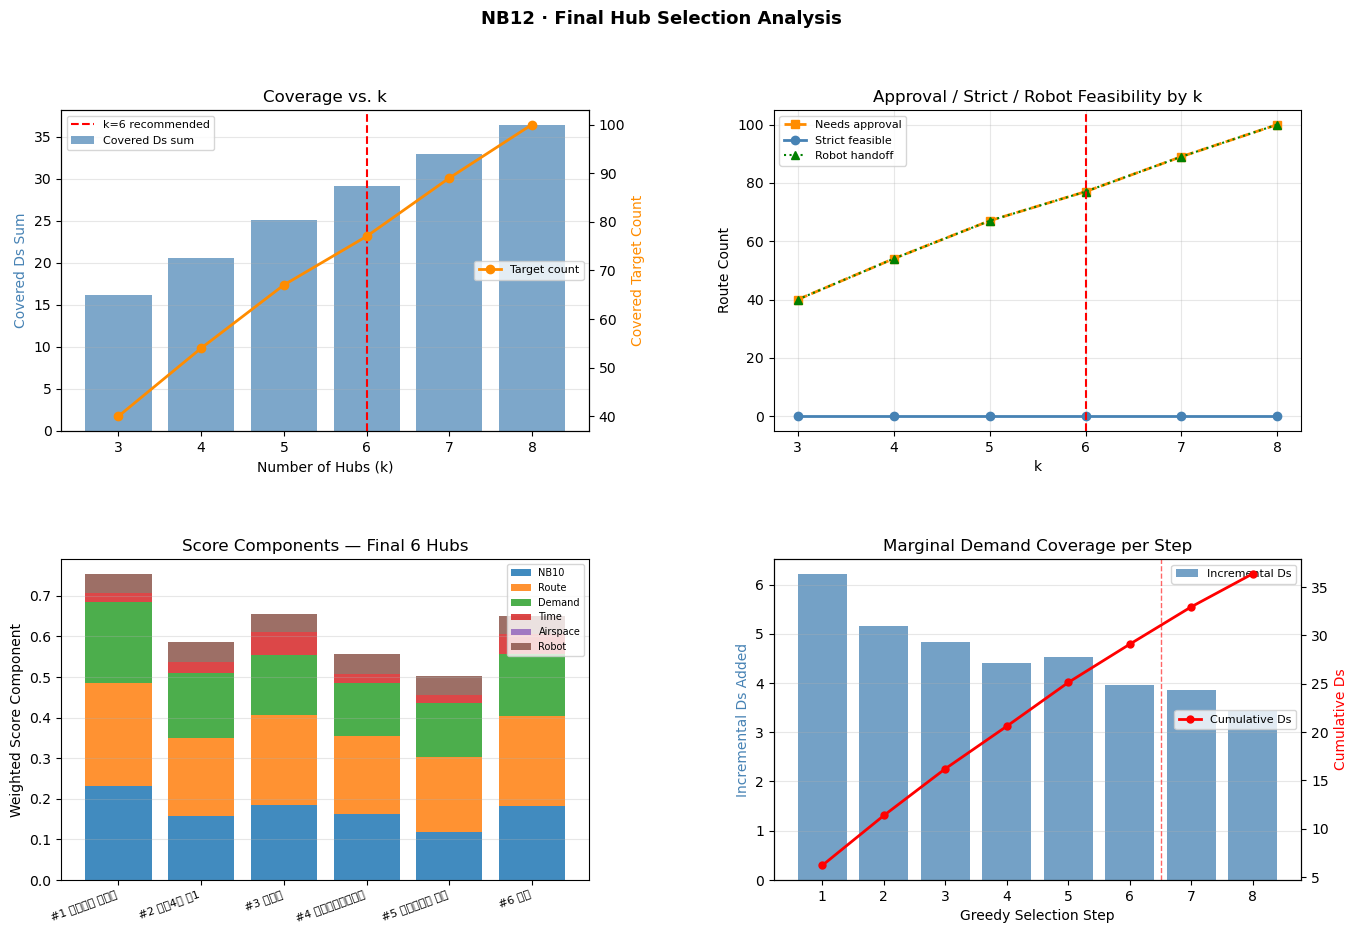

✓ nb12_selection_chart.png saved


In [12]:
# ── CELL 12 · Selection Charts ────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 12a: Coverage curve (k = 3…8) ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1b = ax1.twinx()
ks   = scenarios['k'].values
ds_v = scenarios['covered_Ds_sum'].values
ct_v = scenarios['covered_target_count'].values
ax1.bar(ks, ds_v, color='steelblue', alpha=0.7, label='Covered Ds sum')
ax1b.plot(ks, ct_v, 'o-', color='darkorange', lw=2, label='Target count')
ax1.axvline(K_RECOMMENDED, color='red', linestyle='--', lw=1.5, label=f'k={K_RECOMMENDED} recommended')
ax1.set_xlabel('Number of Hubs (k)')
ax1.set_ylabel('Covered Ds Sum', color='steelblue')
ax1b.set_ylabel('Covered Target Count', color='darkorange')
ax1.set_title('Coverage vs. k')
ax1.legend(loc='upper left', fontsize=8)
ax1b.legend(loc='center right', fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# ── 12b: Approval vs strict feasible routes (per k) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ks, scenarios['airspace_approval_required_route_count'], 's--',
         color='darkorange', lw=2, label='Needs approval')
ax2.plot(ks, scenarios['strict_feasible_route_count'], 'o-',
         color='steelblue', lw=2, label='Strict feasible')
ax2.plot(ks, scenarios['robot_handoff_feasible_route_count'], '^:',
         color='green', lw=1.5, label='Robot handoff')
ax2.axvline(K_RECOMMENDED, color='red', linestyle='--', lw=1.5)
ax2.set_xlabel('k')
ax2.set_ylabel('Route Count')
ax2.set_title('Approval / Strict / Robot Feasibility by k')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 12c: Final hub score components (bar chart) ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
hub_labels = [f'#{int(r["selected_order"])} {lotname_map.get(r["lot_id"],r["lot_id"])[:8]}'
              for r in rec_log]
comp_cols  = ['_n_nb10', '_n_route', '_n_demand', '_n_time', '_n_airsp', '_n_robot']
comp_labels= ['NB10', 'Route', 'Demand', 'Time', 'Airspace', 'Robot']
comp_weights= [W_NB10, W_ROUTE, W_DEMAND, W_TIME, W_AIRSP, W_ROBOT]
comp_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

# Recompute normalised components for selected hubs only
sel_cands = cands_eligible[cands_eligible['lot_id'].isin(sel_lot_ids)].copy()
all_cands_for_norm = cands_eligible.copy()

comp_matrix = np.zeros((len(sel_lot_ids), len(comp_cols)))
raw_map = {
    '_n_nb10':   ('candidate_score_for_ranking', False),
    '_n_route':  ('route_feasibility_index_approval', False),
    '_n_demand': ('served_Ds_sum_approval', False),
    '_n_time':   ('demand_weighted_drone_time_min', True),
    '_n_airsp':  (None, True),   # approval_ratio — handled separately
    '_n_robot':  ('robot_handoff_feasible_count', False),
}
total_pairs_all = all_cands_for_norm['total_route_pairs'].replace(0, np.nan)
approval_ratio_all = all_cands_for_norm['airspace_approval_required_count'].fillna(0) / total_pairs_all.fillna(1)

for i, lid in enumerate(sel_lot_ids):
    row_ = all_cands_for_norm[all_cands_for_norm['lot_id'] == lid]
    if len(row_) == 0:
        continue
    row_ = row_.iloc[0]
    for j, ckey in enumerate(comp_cols):
        col, inv = raw_map[ckey]
        if col is None:
            # approval_ratio for this hub
            tp = row_['total_route_pairs'] if row_['total_route_pairs'] > 0 else 1
            ratio_this = row_['airspace_approval_required_count'] / tp
            # normalise using global series
            mn, mx = approval_ratio_all.min(), approval_ratio_all.max()
            val = (ratio_this - mn) / (mx - mn) if mx > mn else 0.5
            comp_matrix[i, j] = (1 - val) * comp_weights[j]  # invert: less approval = better
        else:
            series = all_cands_for_norm[col].fillna(0)
            mn, mx = series.min(), series.max()
            raw_val = float(row_[col]) if pd.notna(row_[col]) else 0
            val = (raw_val - mn) / (mx - mn) if mx > mn else 0.5
            comp_matrix[i, j] = (1 - val if inv else val) * comp_weights[j]

bottom = np.zeros(len(sel_lot_ids))
x_pos  = np.arange(len(sel_lot_ids))
for j, (lbl, col) in enumerate(zip(comp_labels, comp_colors)):
    ax3.bar(x_pos, comp_matrix[:, j], bottom=bottom, label=lbl, color=col, alpha=0.85)
    bottom += comp_matrix[:, j]
ax3.set_xticks(x_pos)
ax3.set_xticklabels(hub_labels, fontsize=8, rotation=20, ha='right')
ax3.set_ylabel('Weighted Score Component')
ax3.set_title(f'Score Components — Final {K_RECOMMENDED} Hubs')
ax3.legend(fontsize=7, loc='upper right')
ax3.grid(alpha=0.3, axis='y')

# ── 12d: Incremental Ds added per greedy step ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
orders = [r['selected_order'] for r in full_log]
inc_ds = [r['incremental_Ds'] for r in full_log]
cum_ds = [r['cumulative_Ds'] for r in full_log]
bars   = ax4.bar(orders, inc_ds, color='steelblue', alpha=0.75, label='Incremental Ds')
ax4b   = ax4.twinx()
ax4b.plot(orders, cum_ds, 'ro-', lw=2, markersize=5, label='Cumulative Ds')
ax4.set_xlabel('Greedy Selection Step')
ax4.set_ylabel('Incremental Ds Added', color='steelblue')
ax4b.set_ylabel('Cumulative Ds', color='red')
ax4.set_title('Marginal Demand Coverage per Step')
ax4.axvline(K_RECOMMENDED + 0.5, color='red', linestyle='--', lw=1, alpha=0.6)
ax4.legend(loc='upper right', fontsize=8)
ax4b.legend(loc='center right', fontsize=8)
ax4.grid(alpha=0.3, axis='y')

fig.suptitle('NB12 · Final Hub Selection Analysis', fontsize=13, fontweight='bold')
plt.savefig(PROC / 'nb12_selection_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ nb12_selection_chart.png saved')

In [13]:
# ── CELL 13 · Save All Outputs ────────────────────────────────────────────────

# ── ① nb12_final_hubs.csv ─────────────────────────────────────────────────────
HUBS_CSV_COLS = [
    'lot_id', 'lot_name', 'site_ADM_NM', 'site_GU_NM',
    'selected_order', 'final_hub_base_score', 'greedy_increment_score',
    'candidate_rank', 'candidate_grade', 'candidate_score_for_ranking',
    'route_feasibility_index_approval', 'route_feasibility_index_strict',
    'assigned_target_count', 'assigned_Ds_sum', 'mean_assigned_drone_time_min',
    'assigned_airspace_approval_count', 'assigned_strict_feasible_count',
    'assigned_robot_handoff_count',
    'selection_reason', 'nb12_risk_note',
]
hubs_csv_cols = [c for c in HUBS_CSV_COLS if c in final_hubs.columns]
final_hubs[hubs_csv_cols].to_csv(PROC / 'nb12_final_hubs.csv', index=False, encoding='utf-8-sig')
print(f'✓ nb12_final_hubs.csv — {len(final_hubs)} rows')

# ── ② nb12_final_hubs.gpkg ───────────────────────────────────────────────────
hubs_geo_cols = hubs_csv_cols + ['geometry']
hubs_gdf = gpd.GeoDataFrame(
    final_hubs[[c for c in hubs_geo_cols if c in final_hubs.columns]],
    geometry='geometry',
    crs=final_hubs.crs
).to_crs(CRS_PROJ)
hubs_gdf.to_file(PROC / 'nb12_final_hubs.gpkg', layer='final_hubs', driver='GPKG')
print(f'✓ nb12_final_hubs.gpkg [final_hubs] — {len(hubs_gdf)} rows')

# ── ③ nb12_hub_service_assignments.csv ───────────────────────────────────────
ASSIGN_COLS = [
    'target_h3_index', 'assigned_lot_id', 'assigned_lot_name',
    'target_ADM_NM', 'target_GU_NM',
    'Ds', 'delivery_zone', 'drone_time_min', 'route_mean_constraint_score',
    'airspace_approval_required', 'drone_direct_feasible_strict', 'robot_handoff_feasible',
]
assign_cols = [c for c in ASSIGN_COLS if c in assignment.columns]
assignment[assign_cols].to_csv(PROC / 'nb12_hub_service_assignments.csv', index=False, encoding='utf-8-sig')
print(f'✓ nb12_hub_service_assignments.csv — {len(assignment)} rows')

# ── ④ nb12_selection_scenarios.csv ───────────────────────────────────────────
scenarios.to_csv(PROC / 'nb12_selection_scenarios.csv', index=False, encoding='utf-8-sig')
print(f'✓ nb12_selection_scenarios.csv — {len(scenarios)} scenarios')

# ── ⑤ map and chart already saved ────────────────────────────────────────────
print('✓ nb12_final_hub_map.html  (saved in Cell 11)')
print('✓ nb12_selection_chart.png (saved in Cell 12)')

# ── ⑥ nb12_selection_diagnostics.json ────────────────────────────────────────
diag_out = {
    'nb11_route_pair_count':          int(nb11_pair_count),
    'candidate_h3_coverage_count':    int(cov_count),
    'nb11_counts_match':              nb11_pair_count == cov_count,
    'eligible_candidate_count':       int(len(cands_eligible)),
    'k_recommended':                  K_RECOMMENDED,
    'k_scenarios':                    K_SCENARIOS,
    'selected_lot_ids':               sel_lot_ids,
    'selected_lot_names':             [lotname_map.get(lid, lid) for lid in sel_lot_ids],
    'assigned_target_count':          int(len(assignment)),
    'assigned_Ds_sum':                float(round(assignment['Ds'].sum(), 4)),
    'strict_feasible_assigned':       int(assignment['drone_direct_feasible_strict'].sum()),
    'airspace_approval_assigned':     int(assignment['airspace_approval_required'].sum()),
    'robot_handoff_assigned':         int(assignment['robot_handoff_feasible'].sum()),
    'hubs_zero_strict_assigned':      hubs_zero_strict,
    'scenario_Ds_sums':               {str(row['k']): float(row['covered_Ds_sum'])
                                       for _, row in scenarios.iterrows()},
    'primary_scenario':               'approval_required',
    'note':                           '관제권 treated as flag only in primary scenario. Strict scenario for sensitivity.',
}
with open(PROC / 'nb12_selection_diagnostics.json', 'w', encoding='utf-8') as f:
    json.dump(diag_out, f, indent=2, ensure_ascii=False)
print('✓ nb12_selection_diagnostics.json')

✓ nb12_final_hubs.csv — 6 rows
✓ nb12_final_hubs.gpkg [final_hubs] — 6 rows
✓ nb12_hub_service_assignments.csv — 77 rows
✓ nb12_selection_scenarios.csv — 6 scenarios
✓ nb12_final_hub_map.html  (saved in Cell 11)
✓ nb12_selection_chart.png (saved in Cell 12)
✓ nb12_selection_diagnostics.json


In [14]:
# ── CELL 14 · Final Validation ────────────────────────────────────────────────
print('=' * 68)
print('NB12 · FINAL VALIDATION')
print('=' * 68)

errors = []

def _ok(label, val=None, *, assert_val=None, op='==', warn=False):
    tag = '⚠' if warn else ('✓' if assert_val is None else '')
    if assert_val is not None:
        ok = (val == assert_val if op == '==' else
              val <= assert_val if op == '<=' else
              val >= assert_val if op == '>=' else True)
        tag = '✓' if ok else '✗'
        if not ok:
            errors.append(f'{label}: {val} {op} {assert_val} FAILED')
    print(f'  {tag}  {label}' + (f': {val}' if val is not None else ''))

# Required inputs
_ok('All NB11 required files found', assert_val=True, val=all(p.exists() for p in NB11_REQUIRED))
_ok('All other required files found', assert_val=True, val=all(p.exists() for p in OTHER_REQUIRED))

# Row-count consistency
_ok('nb11_route_pairs == candidate_h3_coverage', nb11_pair_count, assert_val=cov_count)

# Candidate counts
_ok(f'Eligible candidates (≥{MIN_ELIGIBLE_APPROVAL} approval route)', len(cands_eligible))
_ok(f'unique lot_id in eligible candidates', cands_eligible['lot_id'].nunique())

# Selection
_ok(f'Selected hub count == {K_RECOMMENDED}',
    len(sel_lot_ids), assert_val=K_RECOMMENDED,
    warn=(len(sel_lot_ids) < K_RECOMMENDED))
_ok('Selected lot_id values are unique', assert_val=True,
    val=(len(sel_lot_ids) == len(set(sel_lot_ids))))

# Assignment
_ok('Assigned target_h3_index unique', assert_val=True,
    val=(assignment['target_h3_index'].nunique() == len(assignment)))
_ok('Assigned target count', len(assignment))
_ok('Assigned Ds sum', round(float(assignment['Ds'].sum()), 4))

# Geometry
_ok('No selected hub has null geometry', assert_val=True,
    val=final_hubs.geometry.notna().all())

# Scenario table
_ok(f'Scenario table contains k=3..8', assert_val=True,
    val=(set(scenarios['k'].tolist()) >= {3,4,5,6,7,8}))

# Strict constraint check
n_str_assigned = int(assignment['drone_direct_feasible_strict'].sum())
n_app_assigned = int(assignment['airspace_approval_required'].sum())
_ok(f'Strict-feasible assigned targets', n_str_assigned)
_ok(f'Approval-required assigned targets', n_app_assigned)

if hubs_zero_strict:
    print(f'  ⚠  Hubs with zero strict-feasible assigned zones: {hubs_zero_strict}')
    print('      These hubs rely entirely on 관제권 airspace approval.')

# Output files
print('\nOutput file check:')
required_outputs = [
    'nb12_final_hubs.csv',
    'nb12_final_hubs.gpkg',
    'nb12_hub_service_assignments.csv',
    'nb12_selection_scenarios.csv',
    'nb12_final_hub_map.html',
    'nb12_selection_chart.png',
    'nb12_selection_diagnostics.json',
]
for fn in required_outputs:
    p = PROC / fn
    if p.exists() and p.stat().st_size > 0:
        print(f'  ✓  {fn}  ({p.stat().st_size / 1024:.1f} KB)')
    else:
        msg = f'MISSING or EMPTY'
        print(f'  ✗  {fn}  {msg}')
        errors.append(fn)

print('\n' + '=' * 68)
if errors:
    print(f'NB12 VALIDATION FAILED — {len(errors)} issue(s):')
    for e in errors:
        print(f'  ✗ {e}')
else:
    print(f'NB12 VALIDATION PASSED — {K_RECOMMENDED} hubs selected, ready for NB13')
print('=' * 68)

NB12 · FINAL VALIDATION
  ✓  All NB11 required files found: True
  ✓  All other required files found: True
  ✓  nb11_route_pairs == candidate_h3_coverage: 2089
  ✓  Eligible candidates (≥1 approval route): 171
  ✓  unique lot_id in eligible candidates: 171
  ✓  Selected hub count == 6: 6
  ✓  Selected lot_id values are unique: True
  ✓  Assigned target_h3_index unique: True
  ✓  Assigned target count: 77
  ✓  Assigned Ds sum: 29.0887
  ✓  No selected hub has null geometry: True
  ✓  Scenario table contains k=3..8: True
  ✓  Strict-feasible assigned targets: 0
  ✓  Approval-required assigned targets: 77
  ⚠  Hubs with zero strict-feasible assigned zones: ['206-3-000001', '204-2-000018', '206-2-000004', '206-2-000022', '206-3-000004', '206-2-000005']
      These hubs rely entirely on 관제권 airspace approval.

Output file check:
  ✓  nb12_final_hubs.csv  (2.2 KB)
  ✓  nb12_final_hubs.gpkg  (96.0 KB)
  ✓  nb12_hub_service_assignments.csv  (11.8 KB)
  ✓  nb12_selection_scenarios.csv  (1.7 KB)